In [1]:
import os
import sys
import numpy as np
sys.path.append('/app/src')
from data_loader import DataLoader
from noise_optimizers import UKF_NoiseOptimizer

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_optimizer_dir = os.path.join(root_path, "exports/_noise_optimizations")
noise_vector_dir = os.path.join(noise_optimizer_dir, "noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = os.path.join(noise_optimizer_dir, "errors/ukf")
noise_vector_export_path = os.path.join(noise_vector_dir, 'ukf')

In [4]:
ukf_optimizer = UKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
ukf_optimizer.run()

Finding optimal noise vector
For setup 1
{'alpha': 1.0, 'beta': 2.0, 'kappa': 0.0}


/app/src/noise_optimizers/ukf_noise_optimizer.py:118: RuntimeWarning: Maximum number of iterations has been exceeded.
  self.result_1 = minimize(self.J, x0_1, bounds=bounds1, method="nelder-mead", options={ 'maxiter': self.max_iter, 'disp': True })


       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 3.089
             x: [ 1.002e+00  1.001e+00 ...  1.003e+00  1.003e+00]
           nit: 500
          nfev: 1937
 final_simplex: (array([[ 1.002e+00,  1.001e+00, ...,  1.003e+00,
                         1.003e+00],
                       [ 1.002e+00,  1.001e+00, ...,  1.003e+00,
                         1.003e+00],
                       ...,
                       [ 1.002e+00,  1.001e+00, ...,  1.003e+00,
                         1.003e+00],
                       [ 1.002e+00,  1.001e+00, ...,  1.003e+00,
                         1.003e+00]]), array([ 3.089e+00,  3.517e+00, ...,  3.827e+00,  3.827e+00]))
For setup 2


/app/src/noise_optimizers/ukf_noise_optimizer.py:128: RuntimeWarning: Maximum number of iterations has been exceeded.
  self.result_2 = minimize(self.J, x0_2, bounds=bounds2, method="nelder-mead", options={ 'maxiter': self.max_iter, 'disp': True })


       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 1.471
             x: [ 1.006e+00  9.896e-01 ...  9.935e-01  1.008e+00]
           nit: 500
          nfev: 3065
 final_simplex: (array([[ 1.006e+00,  9.896e-01, ...,  9.935e-01,
                         1.008e+00],
                       [ 1.006e+00,  9.896e-01, ...,  9.935e-01,
                         1.008e+00],
                       ...,
                       [ 1.006e+00,  9.896e-01, ...,  9.935e-01,
                         1.008e+00],
                       [ 1.006e+00,  9.896e-01, ...,  9.935e-01,
                         1.008e+00]]), array([ 1.471e+00,  1.542e+00, ...,  1.559e+00,  1.625e+00]))
For setup 3
Optimization terminated successfully.
         Current function value: 0.699000
         Iterations: 129
         Function evaluations: 276
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.699

In [6]:
ukf_optimizer.compare(load_exported=True)

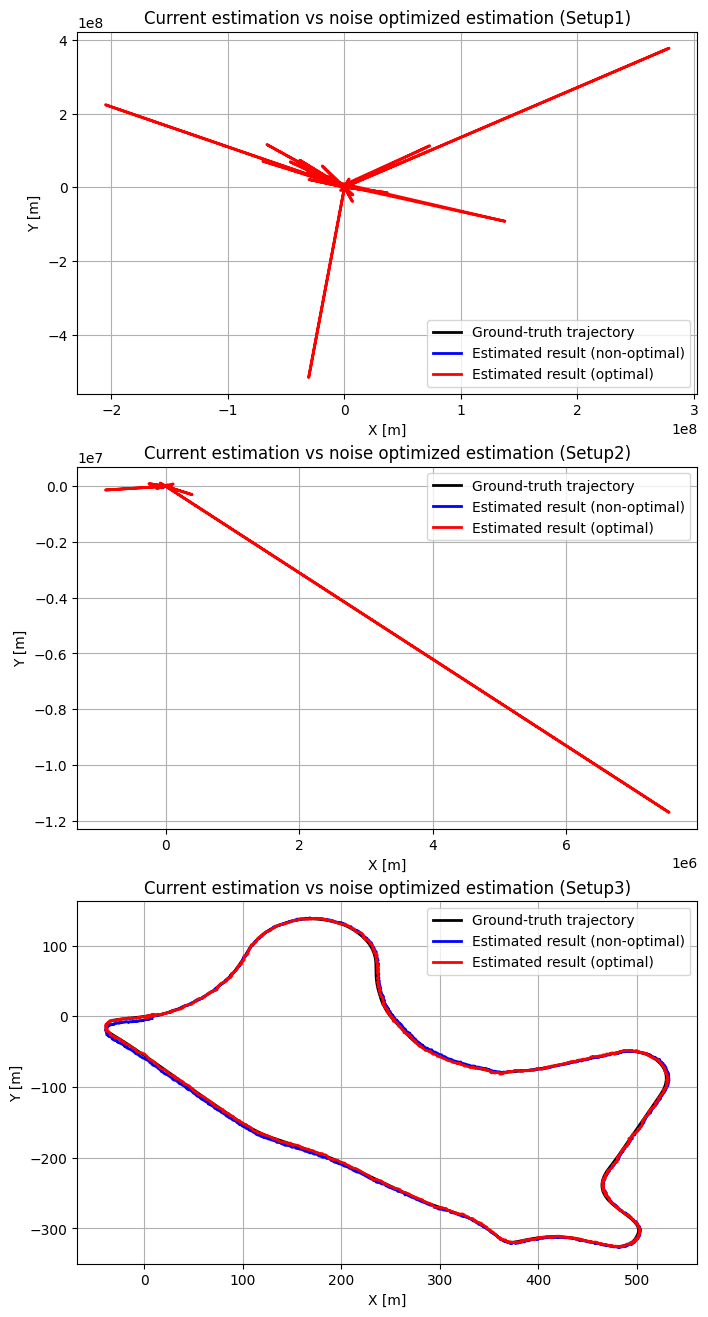

In [7]:
ukf_optimizer.visualize_results()

In [8]:
ukf_optimizer.error_df

Setups        Setup1(IMU+VO)                             Setup2(IMU+VO,GPS)  \
Error types              MAE          RMSE           MAX                MAE   
Non-optimized         82.288  8.694410e+02  2.369399e+04            112.393   
Optimized        4915878.759  2.456596e+07  5.169945e+08          17119.307   
∆                4915796.471  2.456509e+07  5.169708e+08          17006.914   

Setups                                  Setup3(INS)                
Error types          RMSE           MAX         MAE   RMSE    MAX  
Non-optimized    1877.674  5.770061e+04       2.465  3.040  8.766  
Optimized      312692.528  1.170406e+07       0.699  0.893  3.362  
∆              310814.854  1.164636e+07      -1.766 -2.147 -5.404